In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [38]:
file_path = "Student_Dropout_App/Student droupout and academic sucess.csv"


df = pd.read_csv(file_path, sep=";")

In [39]:

print(df.head())


print(df.shape)


print(df.columns.tolist())


print(df.dtypes)


print(df.info())


print(df.describe(include="all"))

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

CLEAN COLUMN NAMES

In [40]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("\nCLEANED COLUMNS ")
print(df.columns.tolist())


CLEANED COLUMNS 
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Targ

CHECK MISSING VALUES

In [41]:
missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:",
      df.isnull().sum().sum())


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

CHECK DUPLICATES

In [42]:
print("Number of duplicate rows:",
      df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

print("Shape after removing duplicates:",
      df.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (4424, 37)


TARGET DISTRIBUTION

In [43]:
print("\n========== TARGET DISTRIBUTION ==========")

print(df["Target"].value_counts())

print("\nTarget percentage:")
print(
    df["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)



========== TARGET DISTRIBUTION ==========
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target percentage:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


TARGET VISUALIZATION

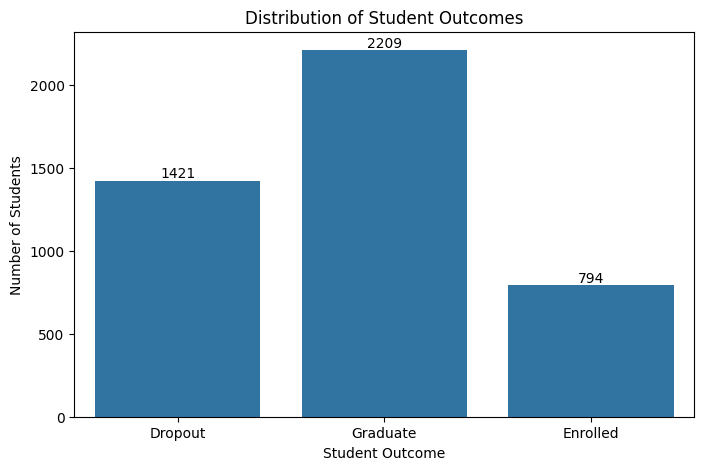

In [44]:
# Target distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Target"
)

plt.title("Distribution of Student Outcomes")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

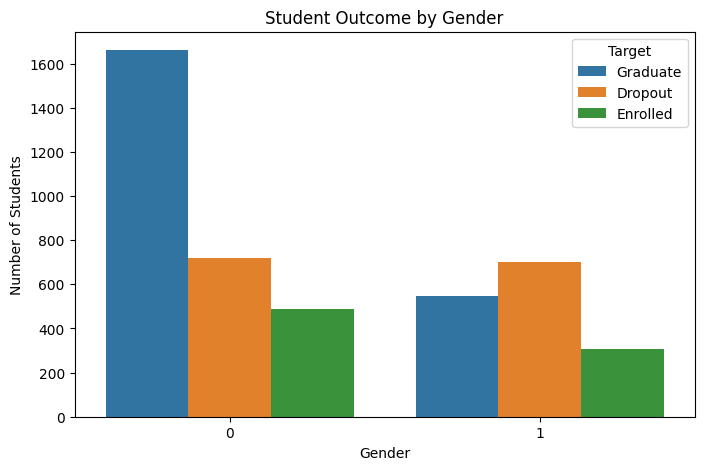

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Target"
)

plt.title("Student Outcome by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

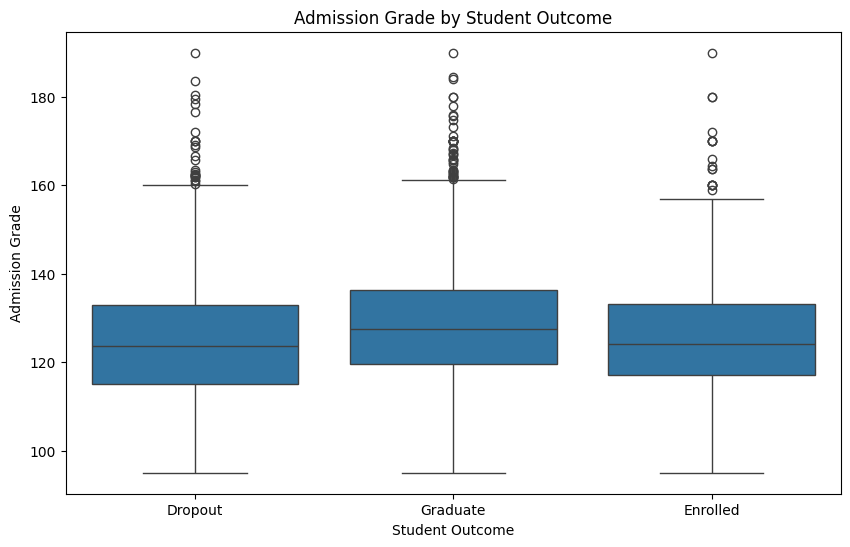

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade"
)

plt.title("Admission Grade by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Admission Grade")

plt.show()

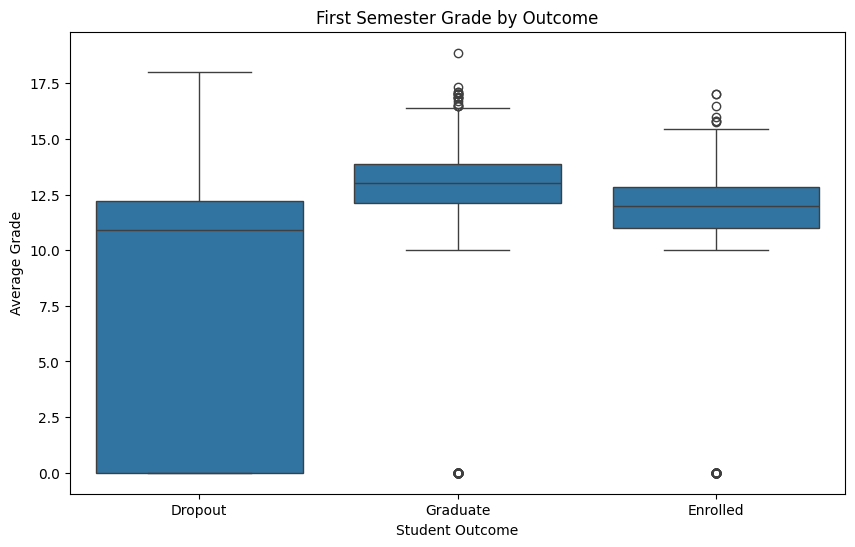

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)"
)

plt.title("First Semester Grade by Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average Grade")

plt.show()

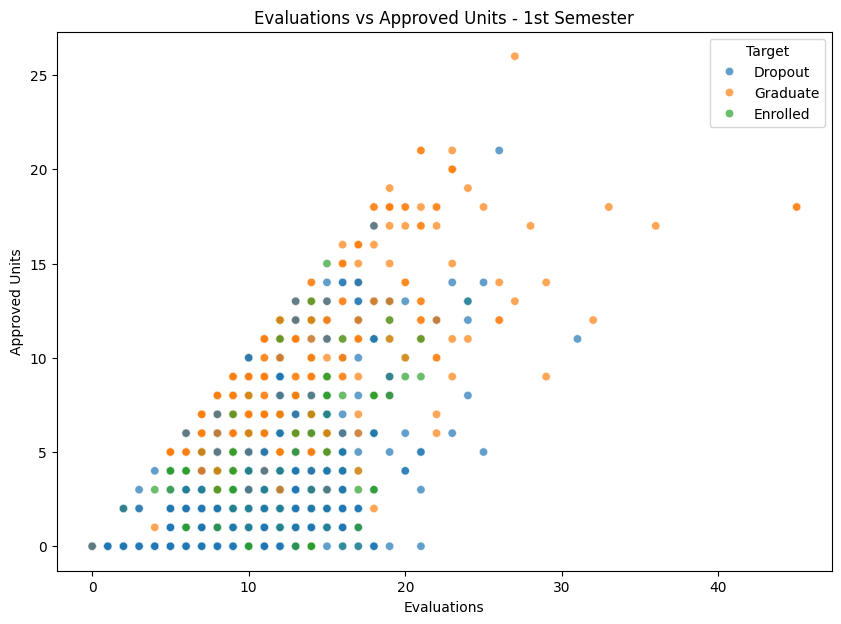

In [48]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Curricular units 1st sem (evaluations)",
    y="Curricular units 1st sem (approved)",
    hue="Target",
    alpha=0.7
)

plt.title("Evaluations vs Approved Units - 1st Semester")
plt.xlabel("Evaluations")
plt.ylabel("Approved Units")

plt.show()

In [72]:
numeric_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("\n========== CATEGORICAL COLUMNS ==========")

print(categorical_columns)

print("\n========== NUMERIC COLUMNS ==========")

print(numeric_columns)


========== CATEGORICAL COLUMNS ==========
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

========== NUMERIC COLUMNS ==========
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without e

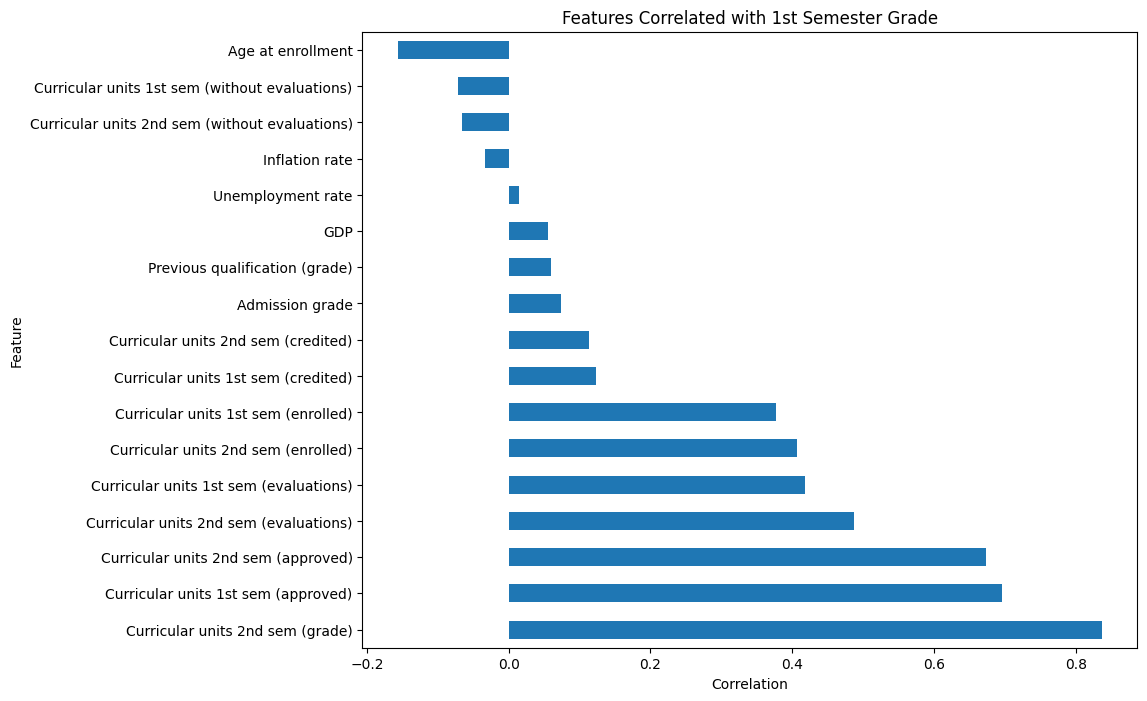

In [73]:
correlation_with_grade = (
    df[numeric_columns]
    .corr()["Curricular units 1st sem (grade)"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

correlation_with_grade.drop(
    "Curricular units 1st sem (grade)"
).plot(
    kind="barh"
)

plt.title(
    "Features Correlated with 1st Semester Grade"
)

plt.xlabel("Correlation")

plt.ylabel("Feature")

plt.show()

In [79]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Features for Student Outcome Prediction"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

NameError: name 'feature_importance' is not defined

CHECK TARGET VALUES

In [ ]:
print(df["Target"].unique())

CHECK NUMERIC CORRELATION

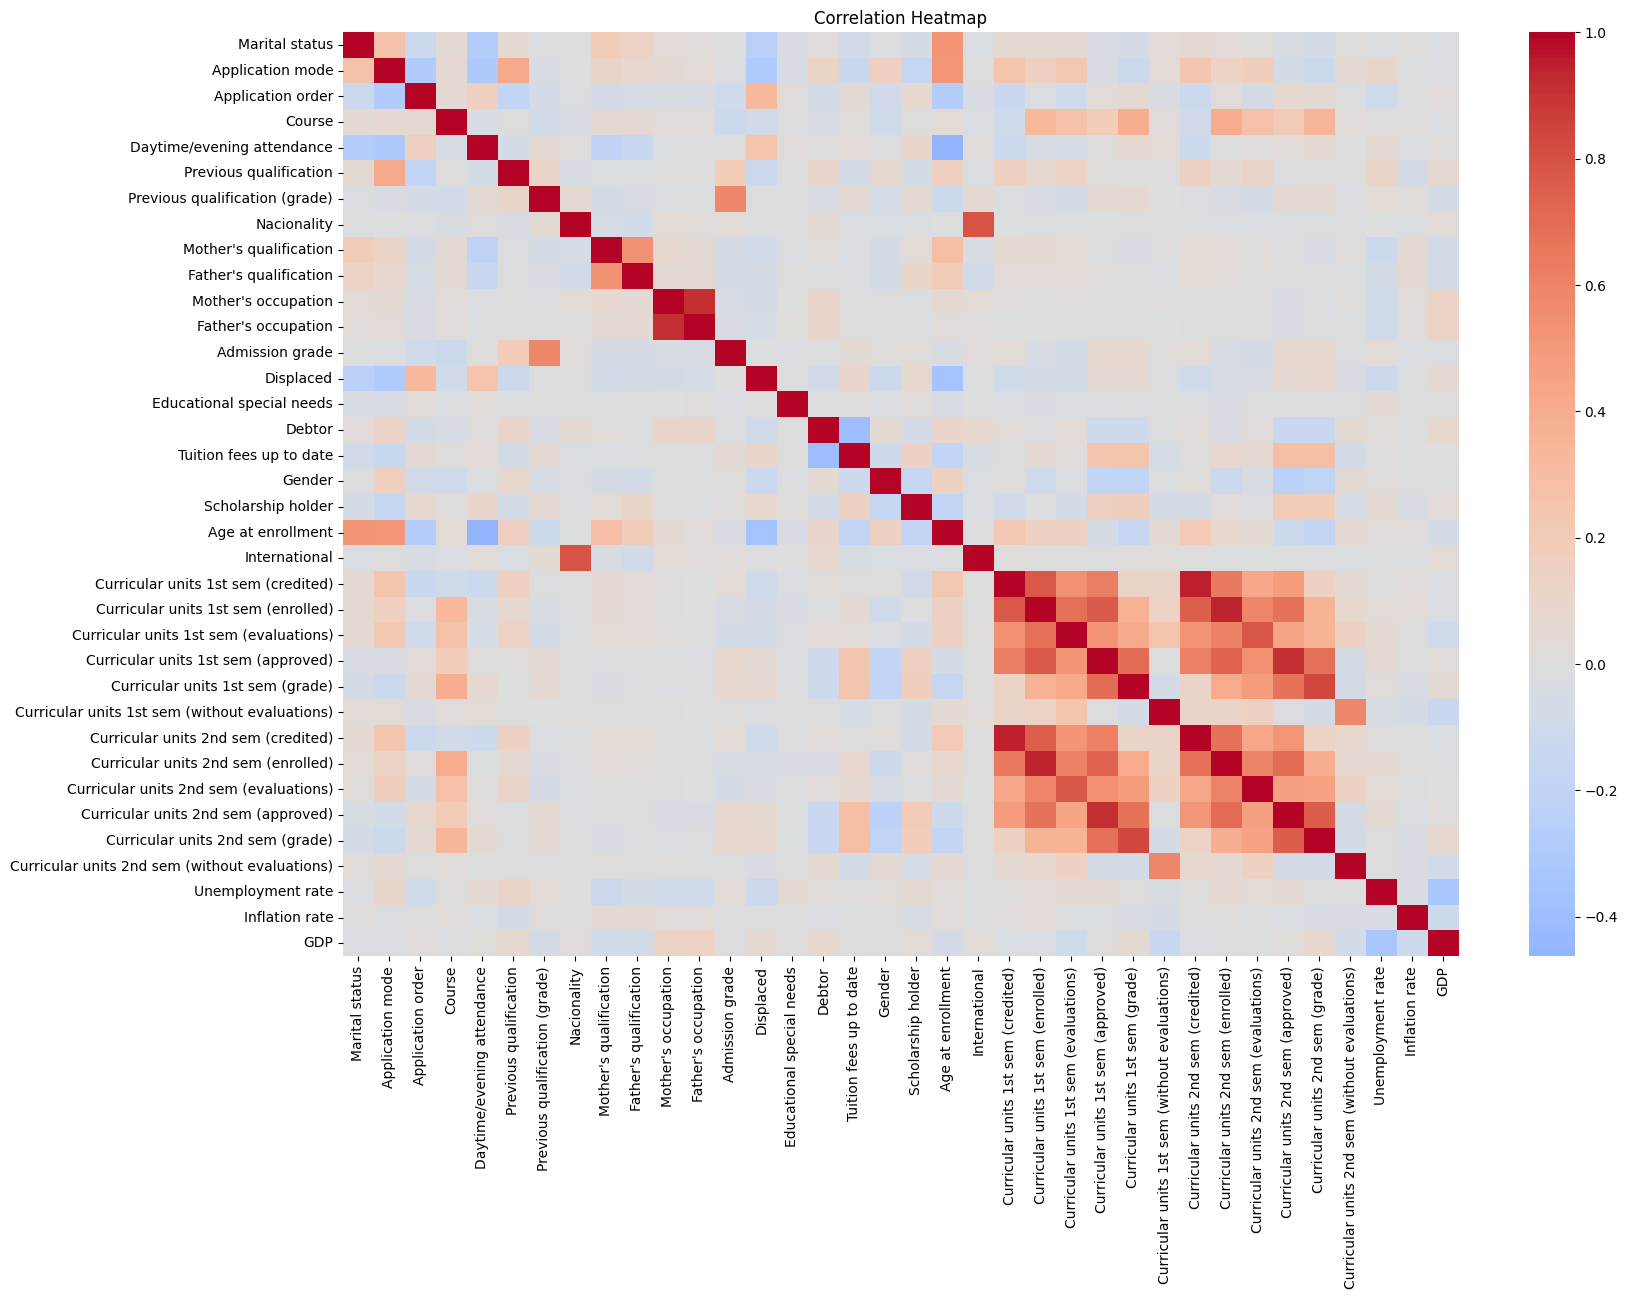

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18, 12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

SELECT TARGET

In [50]:
X = df.drop("Target", axis=1)

y = df["Target"]

DEFINE CATEGORICAL COLUMNS

In [51]:
categorical_columns = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]


In [52]:
#MAKE SURE COLUMNS EXIST
categorical_columns = [
    col for col in categorical_columns
    if col in X.columns
]

IDENTIFY NUMERIC COLUMNS

In [53]:
numeric_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("\n========== CATEGORICAL COLUMNS ==========")

print(categorical_columns)

print("\n========== NUMERIC COLUMNS ==========")

print(numeric_columns)


========== CATEGORICAL COLUMNS ==========
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

========== NUMERIC COLUMNS ==========
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without e

TRAIN TEST SPLIT

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)



Training data: (3539, 36)
Testing data: (885, 36)


PREPROCESSING

In [55]:
# Numerical preprocessing:
# Missing values -> median
# Scaling -> StandardScaler

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# Missing values -> most frequent
# Convert categories into One-Hot Encoding

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine both preprocessing methods

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)



CREATE MACHINE LEARNING MODELS

In [56]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Decision Tree": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

TRAIN AND COMPARE MODELS

In [57]:
results = []

trained_models = {}

for name, model in models.items():

    print("\n======================================")
    print("Training:", name)
    print("======================================")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline

    print("\nAccuracy:",
          round(accuracy, 4))

    print("Precision:",
          round(precision, 4))

    print("Recall:",
          round(recall, 4))

    print("F1 Score:",
          round(f1, 4))




Training: Logistic Regression

Accuracy: 0.7232
Precision: 0.765
Recall: 0.7232
F1 Score: 0.7369

Training: Random Forest

Accuracy: 0.7695
Precision: 0.754
Recall: 0.7695
F1 Score: 0.7514

Training: Decision Tree

Accuracy: 0.7492
Precision: 0.7289
Recall: 0.7492
F1 Score: 0.7273


MODEL COMPARISON

In [58]:
results_df = pd.DataFrame(results)

print("\n MODEL COMPARISON ")

print(
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
)



 MODEL COMPARISON 
                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.769492   0.754003  0.769492  0.751365
0  Logistic Regression  0.723164   0.765029  0.723164  0.736925
2        Decision Tree  0.749153   0.728857  0.749153  0.727283


VISUALIZE MODEL PERFORMANCE

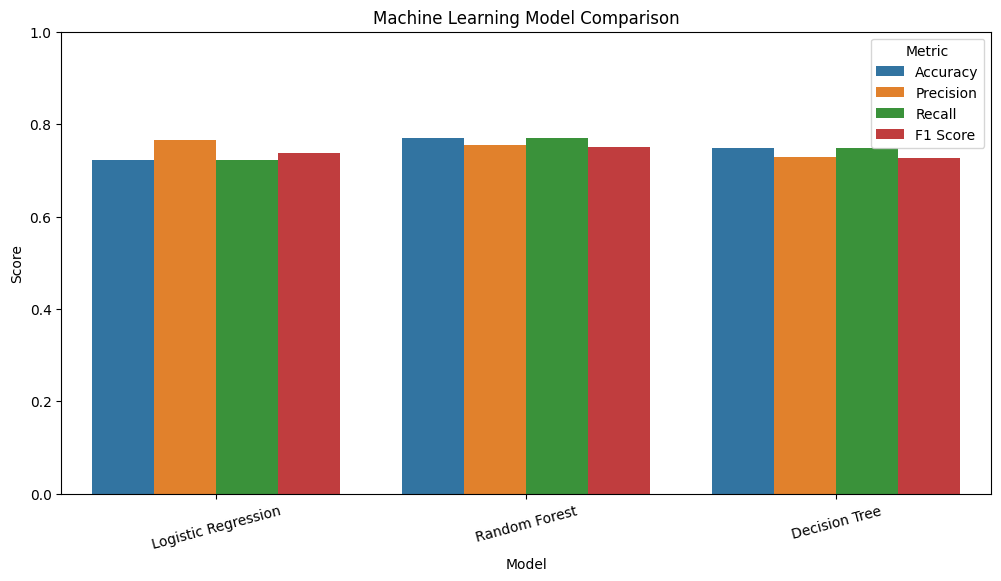

In [59]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()


SELECT BEST MODEL

In [60]:
best_model_name = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = trained_models[
    best_model_name
]

print("\n======================================")
print("BEST MODEL:", best_model_name)
print("======================================")



BEST MODEL: Random Forest


FINAL PREDICTION

In [61]:
y_pred = best_model.predict(X_test)

CLASSIFICATION REPORT

In [62]:
#print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.59      0.33      0.42       159
    Graduate       0.79      0.94      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.75      0.77      0.75       885



CONFUSION MATRIX

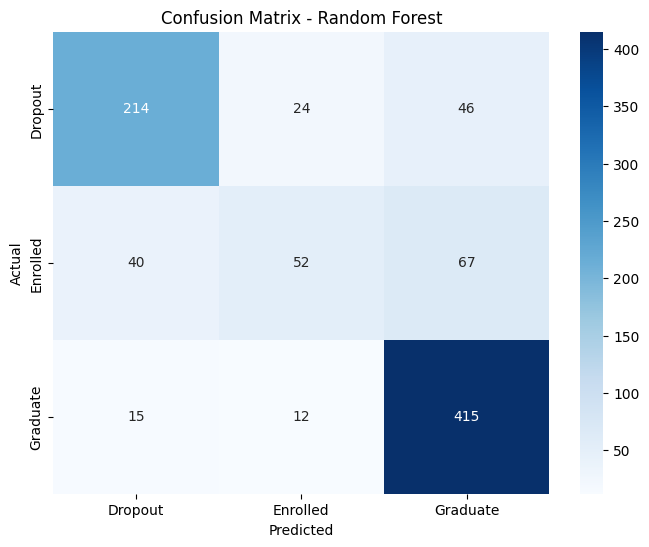

In [63]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - " +
    best_model_name
)

plt.show()


SAVE BEST MODEL

In [66]:
joblib.dump(
    best_model,
    "Student_Dropout_App/student_dropout_model.pkl"
)

print(
    "\nBest model saved as:"
    " student_dropout_model.pkl"
)



Best model saved as: student_dropout_model.pkl


LOAD SAVED MODEL

In [67]:
loaded_model = joblib.load(
    "Student_Dropout_App/student_dropout_model.pkl"
)


PREDICT A NEW STUDENT

In [68]:
new_student = pd.DataFrame([
    {
        "Marital status": 1,
        "Application mode": 17,
        "Application order": 5,
        "Course": 171,
        "Daytime/evening attendance": 1,
        "Previous qualification": 1,
        "Previous qualification (grade)": 122.0,
        "Nacionality": 1,
        "Mother's qualification": 19,
        "Father's qualification": 12,
        "Mother's occupation": 5,
        "Father's occupation": 9,
        "Admission grade": 127.3,
        "Displaced": 1,
        "Educational special needs": 0,
        "Debtor": 0,
        "Tuition fees up to date": 1,
        "Gender": 1,
        "Scholarship holder": 0,
        "Age at enrollment": 20,
        "International": 0,

        "Curricular units 1st sem (credited)": 0,
        "Curricular units 1st sem (enrolled)": 0,
        "Curricular units 1st sem (evaluations)": 0,
        "Curricular units 1st sem (approved)": 0,
        "Curricular units 1st sem (grade)": 0.0,
        "Curricular units 1st sem (without evaluations)": 0,

        "Curricular units 2nd sem (credited)": 0,
        "Curricular units 2nd sem (enrolled)": 0,
        "Curricular units 2nd sem (evaluations)": 0,
        "Curricular units 2nd sem (approved)": 0,
        "Curricular units 2nd sem (grade)": 0.0,
        "Curricular units 2nd sem (without evaluations)": 0,

        "Unemployment rate": 10.8,
        "Inflation rate": 1.4,
        "GDP": 1.74
    }
])

In [69]:
prediction = loaded_model.predict(
    new_student
)

print("\n========== NEW STUDENT PREDICTION ==========")

print("Predicted Status:",
      prediction[0])


========== NEW STUDENT PREDICTION ==========
Predicted Status: Dropout


PREDICTION PROBABILITY

In [70]:
probabilities = loaded_model.predict_proba(
    new_student
)

probability_df = pd.DataFrame(
    probabilities,
    columns=loaded_model.classes_
)

print("\n========== PREDICTION PROBABILITIES ==========")

print(probability_df)



========== PREDICTION PROBABILITIES ==========
   Dropout  Enrolled  Graduate
0     0.84      0.04      0.12


SHOW MOST LIKELY CLASS

In [71]:
prediction_probability = probabilities[0].max()

print(
    "\nPrediction confidence:",
    round(prediction_probability * 100, 2),
    "%"
)


Prediction confidence: 84.0 %
